# Testing

In [6]:
import sys
sys.path.append("../src")

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from DSM import (
    ode,
    make_observations,
    adverse_load,
    as_function,
    treatment_short,
    treatment_long,
)

In [15]:
# --- Setup -----------------------------------------------------------------
t_span = (0, 10)
t_grid = np.linspace(*t_span, 200)
y0 = np.array([0.5, 0.5, 0.5])

# Model parameters
params = dict(a=0.8, b=0.5,
              cs=1.0,    # short-term treatment effect on active disease
              cl=1e-3,   # long-term treatment effect on active disease (very small)
              qs=0.5,    # short-term treatment effect on symptom recovery
              k=1.0, r=0.8,
              eps=0.3, m=1.0, gc=0.6,
              nl=1.0)    # long-term treatment effect on chronic degradation

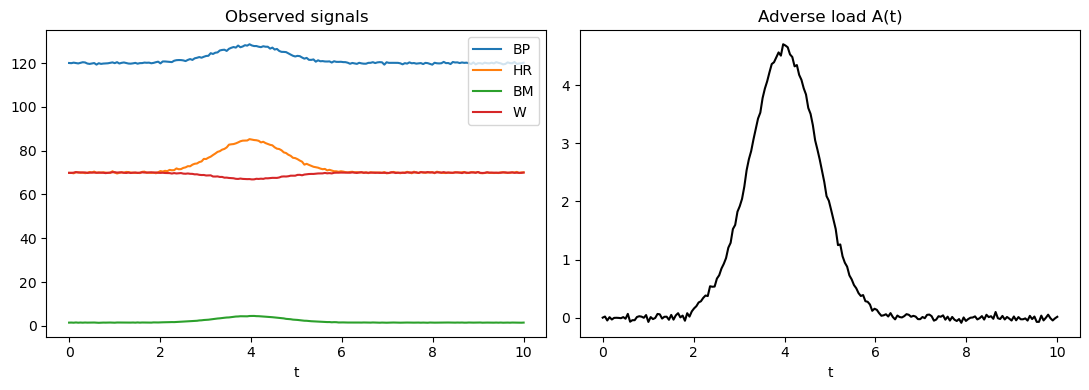

In [16]:
# --- Observed signals -> adverse load A(t) ---------------------------------
# Synthetic BP / HR / BM / W time series with a flare around t = 4.
obs = make_observations(t_grid, flare_times=[4.0], noise=0.02, seed=0)

A_vals = adverse_load(obs)          # combine signals into adverse load
A_fun = as_function(t_grid, A_vals)  # callable A(t) for the solver

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for key, sig in obs.items():
    ax[0].plot(t_grid, sig, label=key)
ax[0].set_title("Observed signals")
ax[0].set_xlabel("t")
ax[0].legend()

ax[1].plot(t_grid, A_vals, color="k")
ax[1].set_title("Adverse load A(t)")
ax[1].set_xlabel("t")
plt.tight_layout()
plt.show()

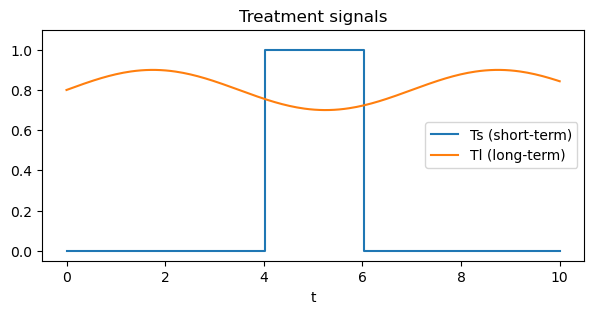

In [17]:
# --- Treatment: short-term (acute) vs long-term (maintenance) --------------
# Short-term: a single acute course covering the flare, [start, start+dur).
Ts = lambda tau: treatment_short(tau, courses=[(4.0, 2.0)])
# Long-term: steady maintenance adherence with a mild fluctuation.
Tl = lambda tau: treatment_long(tau, level=0.8, amp=0.1, period=7.0)

plt.figure(figsize=(7, 3))
plt.step(t_grid, Ts(t_grid), where="post", label="Ts (short-term)")
plt.plot(t_grid, Tl(t_grid), label="Tl (long-term)")
plt.ylim(-0.05, 1.1)
plt.xlabel("t")
plt.title("Treatment signals")
plt.legend()
plt.show()

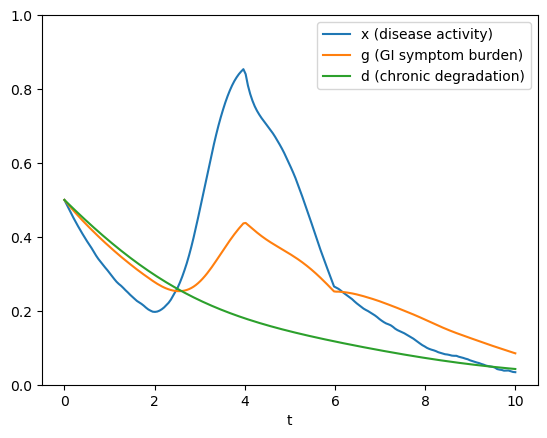

In [18]:
# --- Solve the disease-state model -----------------------------------------
args = (params["a"], params["b"], params["cs"], params["cl"], params["qs"],
        params["k"], params["r"], params["eps"], params["m"], params["gc"],
        params["nl"], A_fun, Ts, Tl)

sol = solve_ivp(ode, t_span, y0, args=args, t_eval=t_grid, max_step=0.1)

x, g, d = sol.y

plt.plot(sol.t, x, label="x (disease activity)")
plt.plot(sol.t, g, label="g (GI symptom burden)")
plt.plot(sol.t, d, label="d (chronic degradation)")
plt.legend()
plt.ylim(0, 1)
plt.xlabel("t")
plt.show()